         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

<ipython-input-2-53ba8b74ad69>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
<ipython-input-2-53ba8b74ad69>:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

MSE: 8.746621012769822e-05
R2 Score: 0.9492904069870767


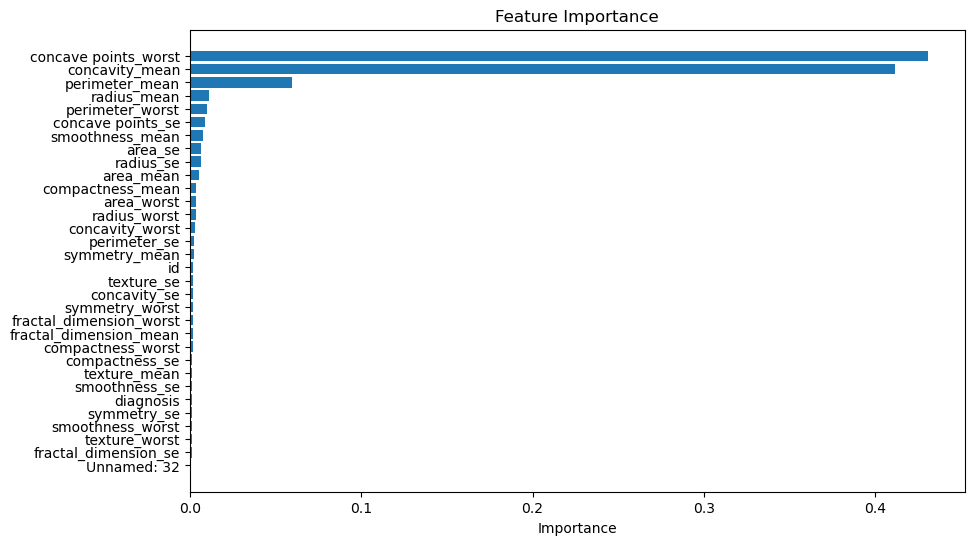

In [2]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv('data (1).csv')

print(df.head())
print(df.info())

# ================================
# 3. Handle Missing Values
# ================================
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ================================
# 4. Encode Categorical Columns
# ================================
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ================================
# 5. Define Features & Target
# ================================
target_column = 'concave points_mean'

X = df.drop(columns=[target_column])
y = df[target_column]

# ================================
# 6. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. Choose Model Type
# ================================
# This will likely be regression because the target looks numeric
if y.nunique() <= 20:
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    task = "classification"
else:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    task = "regression"

# ================================
# 8. Train Model
# ================================
model.fit(X_train, y_train)

# ================================
# 9. Predictions
# ================================
y_pred = model.predict(X_test)

# ================================
# 10. Evaluation
# ================================
if task == "classification":
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
else:
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

# ================================
# 11. Feature Importance
# ================================
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance")
plt.show()